**Import Library & Load Data**

In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv('german_credit_data.csv', index_col = 0)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


**Check for Missing Values**

In [10]:
df.isna().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


**Using desc 'None' for those Missing Values** **bold text**

In [11]:
df['Saving accounts'] = df['Saving accounts'].fillna('none')
df['Checking account'] = df['Checking account'].fillna('none')

In [12]:
df.isna().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


**Encoding: Assign categories to Numbers**

In [13]:
saving_order = ['none','little','moderate','quite rich', 'rich']
df['Saving_enc'] = df['Saving accounts'].map({v: i for i, v in enumerate(saving_order)})

df[['Saving accounts', 'Saving_enc']].head(10)

,Saving accounts,Saving_enc
0,none,0
1,little,1
2,little,1
3,little,1
4,little,1
5,none,0
6,quite rich,3
7,little,1
8,rich,4
9,little,1


**Encoding all others column**

In [14]:
checking_order = ['none','little','moderate','rich']

df['Checking_enc'] = df['Checking account'].map({v: i for i, v in enumerate(checking_order)})

df['Sex_enc'] = df['Sex'].map({'male': 0, 'female':1})

df['Housing_enc'] = df['Housing'].map({'rent':0, 'free': 1, 'own':2})

df[['Checking account', 'Checking_enc', 'Sex', 'Sex_enc', 'Housing', 'Housing_enc']].head()

,Checking account,Checking_enc,Sex,Sex_enc,Housing,Housing_enc
0,little,1,male,0,own,2
1,moderate,2,female,1,own,2
2,none,0,male,0,own,2
3,little,1,male,0,free,1
4,little,1,male,0,free,1


****

**Preparing Fiture for Clustering**

In [15]:
features = ['Age', 'Job', 'Housing_enc', 'Saving_enc','Checking_enc','Credit amount','Duration','Sex_enc']
X = df[features].copy()
X.head()

,Age,Job,Housing_enc,Saving_enc,Checking_enc,Credit amount,Duration,Sex_enc
0,67,2,2,0,1,1169,6,0
1,22,2,2,1,2,5951,48,1
2,49,1,2,1,0,2096,12,0
3,45,2,1,1,1,7882,42,0
4,53,2,1,1,1,4870,24,0


**Standarized**

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 2.76645648e+00,  1.46949180e-01,  5.98201345e-01,
        -1.23139326e+00, -1.04541732e-03, -7.45131413e-01,
        -1.23647786e+00, -6.70280063e-01],
       [-1.19140394e+00,  1.46949180e-01,  5.98201345e-01,
        -1.96609009e-01,  1.04437190e+00,  9.49816789e-01,
         2.24819436e+00,  1.49191369e+00],
       [ 1.18331231e+00, -1.38377145e+00,  5.98201345e-01,
        -1.96609009e-01, -1.04646274e+00, -4.16562408e-01,
        -7.38667543e-01, -6.70280063e-01],
       [ 8.31502499e-01,  1.46949180e-01, -6.85492529e-01,
        -1.96609009e-01, -1.04541732e-03,  1.63424694e+00,
         1.75038404e+00, -6.70280063e-01],
       [ 1.53512213e+00,  1.46949180e-01, -6.85492529e-01,
        -1.96609009e-01, -1.04541732e-03,  5.66663505e-01,
         2.56953092e-01, -6.70280063e-01]])

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: silhouette={score:.3f}")

k=2: silhouette=0.184
k=3: silhouette=0.181
k=4: silhouette=0.186
k=5: silhouette=0.161
k=6: silhouette=0.169
k=7: silhouette=0.165


In [18]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_scaled)

df['Cluster'].value_counts()

,count
Cluster,
0,467
2,187
3,185
1,161


In [19]:
profile = df.groupby('Cluster')[['Age', 'Job', 'Credit amount', 'Duration']].mean().round(1)
profile['count'] = df.groupby('Cluster').size()
profile

,Age,Job,Credit amount,Duration,count
Cluster,,,,,
0,37.3,1.8,2241.5,17.2,467
1,29.5,1.8,2479.5,17.0,161
2,35.1,1.8,2056.5,16.3,187
3,36.8,2.3,7787.7,38.2,185


In [20]:
pd.crosstab(df['Cluster'], df['Housing'], normalize = 'index').round(2)


pd.crosstab(df['Cluster'], df['Sex'], normalize = 'index').round(2)

Sex,female,male
Cluster,,
0,0.00,1.00
1,0.57,0.43
2,1.00,0.00
3,0.17,0.83


**Profile Each Cluster**
What Makes Them Different?

In [21]:

pd.crosstab(df['Cluster'], df['Housing'], normalize = 'index').round(2)

Housing,free,own,rent
Cluster,,,
0,0.10,0.90,0.00
1,0.01,0.00,0.99
2,0.06,0.94,0.00
3,0.26,0.63,0.10


In [22]:
pd.crosstab(df['Cluster'], df['Sex'], normalize = 'index').round(2)

Sex,female,male
Cluster,,
0,0.00,1.00
1,0.57,0.43
2,1.00,0.00
3,0.17,0.83


**Compare Categorical Columns Across Clusters**

In [26]:
cluster_names = {
    0: 'Established Male Homeowners',
    1: 'Young Renters',
    2: 'Established Female Homeowners',
    3: 'High-Value Borrowers'
}

df['Segment'] = df['Cluster'].map(cluster_names)
df['Segment'].value_counts()

,count
Segment,
Established Male Homeowners,467
Established Female Homeowners,187
High-Value Borrowers,185
Young Renters,161


**Visualize the Segments**

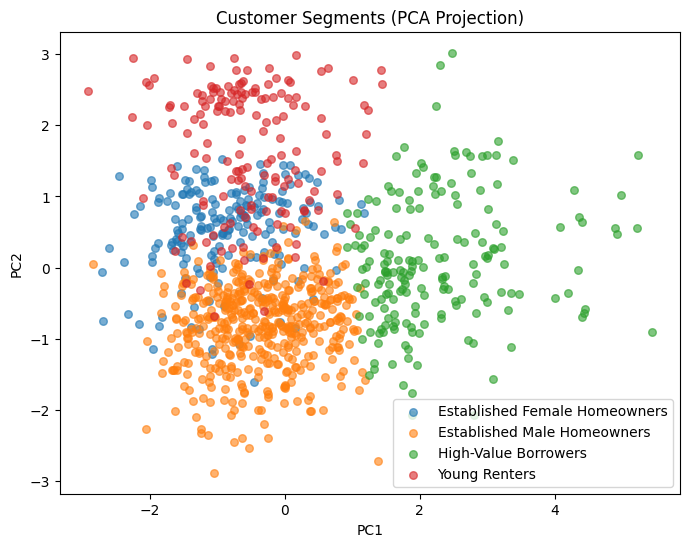

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df['pca1'] = coords[:, 0]
df['pca2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(8,6))
for segment, group in df.groupby('Segment'):
    ax.scatter(group['pca1'], group['pca2'], label=segment, alpha=0.6, s=30)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Customer Segments (PCA Projection)')
ax.legend()
plt.show()